# 🎤 Speaker Verification with X-Vector on Kaggle (2x T4 GPUs)

This notebook implements the end-to-end pipeline for training, evaluating, and exporting an **X-Vector** model for Speaker Verification.

### Pipeline Overview:
1. **Environment Preparation**: Setup dependencies and configure dual GPU training.
2. **Data Pipeline & Augmentation**: Scan VoxCeleb and MUSAN datasets, implement noise mixing at random SNRs, extract 80-dimensional Log-Mel spectrograms, and partition data.
3. **Model Architecture**: Implement the Time Delay Neural Network (TDNN) blocks and Statistics Pooling layers for X-Vector (512-D embeddings).
4. **Training & Validation**: Train on speaker classification and optimize the cosine similarity threshold on validation pairs to maximize **F1-score**.
5. **Visualization**: Plot loss curves, similarity distributions, ROC curves, and EER.
6. **Export**: Export the model and evaluation metadata.

## 🛠️ Step 1: Prepare Environment and Import Libraries

In [1]:
!pip install -q torchaudio soundfile librosa matplotlib seaborn scikit-learn pandas numpy tqdm

import os, re, sys, time, math, random, glob, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, roc_curve, auc
import soundfile as sf
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_everything(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_gpus = torch.cuda.device_count()
print(f'[INFO] Device: {device} | GPUs: {num_gpus}')
for i in range(num_gpus):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')
os.makedirs('checkpoints/xvector', exist_ok=True)
os.makedirs('results', exist_ok=True)

[INFO] Device: cuda | GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


## 🔄 Step 2: Auto-Discover Datasets, Preprocess, and Setup Augmentation
This cell **automatically scans** `/kaggle/input/` to locate VoxCeleb and MUSAN audio files regardless of the exact directory structure.

In [2]:
import warnings
warnings.filterwarnings('ignore')

SR = 16000
DURATION = 3
NUM_SAMPLES = SR * DURATION
N_MELS = 80
BATCH_SIZE = 64
NUM_WORKERS = 4

# ============================================================
# AUTO-DISCOVER DATASET PATHS
# ============================================================
INPUT_ROOT = '/kaggle/input'

print('=' * 60)
print('STEP 1: Discovering /kaggle/input/ structure')
print('=' * 60)
for ds in sorted(os.listdir(INPUT_ROOT)):
    ds_path = os.path.join(INPUT_ROOT, ds)
    if os.path.isdir(ds_path):
        print(f'\n  [DIR] {ds}/')
        for sub in sorted(os.listdir(ds_path))[:15]:
            sub_path = os.path.join(ds_path, sub)
            tag = '[DIR]' if os.path.isdir(sub_path) else '[FILE]'
            print(f'    {tag} {sub}')
            if os.path.isdir(sub_path):
                for sub2 in sorted(os.listdir(sub_path))[:8]:
                    sub2_path = os.path.join(sub_path, sub2)
                    tag2 = '[DIR]' if os.path.isdir(sub2_path) else '[FILE]'
                    print(f'      {tag2} {sub2}')

print(f'\n{"=" * 60}')
print('STEP 2: Searching for all audio files...')
print('=' * 60)
all_wav = glob.glob(os.path.join(INPUT_ROOT, '**', '*.wav'), recursive=True)
all_flac = glob.glob(os.path.join(INPUT_ROOT, '**', '*.flac'), recursive=True)
print(f'  .wav  files found: {len(all_wav)}')
print(f'  .flac files found: {len(all_flac)}')
all_audio = all_wav + all_flac
print(f'  Total audio files: {len(all_audio)}')

if len(all_audio) > 0:
    print('\n  Sample paths:')
    for p in all_audio[:10]:
        print(f'    {p}')

# ============================================================
# CLASSIFY: VoxCeleb vs MUSAN
# ============================================================
print(f'\n{"=" * 60}')
print('STEP 3: Classifying audio files (VoxCeleb vs MUSAN)')
print('=' * 60)

vox_wav_files = []
noise_files = []

for f in all_audio:
    fp = f.replace('\\', '/')
    # VoxCeleb files have speaker IDs like id10001 in their path
    if re.search(r'/id\d{3,}/', fp):
        vox_wav_files.append(f)
    # MUSAN noise files have 'noise' in path (but not 'speech' or 'music')
    elif 'noise' in fp.lower() and 'musan' in fp.lower():
        noise_files.append(f)

# Fallback: if auto-classification found nothing, use broader patterns
if len(vox_wav_files) == 0:
    print('  [WARN] No VoxCeleb files found by id pattern. Trying broader match...')
    for f in all_audio:
        fp = f.replace('\\', '/').lower()
        if 'vox' in fp or 'celeb' in fp:
            vox_wav_files.append(f)

if len(noise_files) == 0:
    print('  [WARN] No MUSAN noise files found. Trying broader match...')
    for f in all_audio:
        fp = f.replace('\\', '/').lower()
        if 'noise' in fp:
            noise_files.append(f)

print(f'  VoxCeleb audio files: {len(vox_wav_files)}')
print(f'  MUSAN noise files:   {len(noise_files)}')

assert len(vox_wav_files) > 0, (
    'ERROR: No VoxCeleb audio files found! '
    'Please check that the VoxCeleb dataset is correctly attached in Kaggle.'
)

# ============================================================
# BUILD SPEAKER DICTIONARY
# ============================================================
def get_speaker_id(path):
    parts = path.replace('\\', '/').split('/')
    for p in parts:
        if re.match(r'^id\d{3,}$', p):
            return p
    return 'unknown'

speaker_dict = {}
for path in vox_wav_files:
    spk_id = get_speaker_id(path)
    if spk_id != 'unknown':
        speaker_dict.setdefault(spk_id, []).append(path)

# If no speaker IDs found, try using parent folder names as speaker IDs
if len(speaker_dict) == 0:
    print('  [WARN] No idXXXXX folders found. Using parent directories as speaker labels.')
    for path in vox_wav_files:
        parts = path.replace('\\', '/').split('/')
        if len(parts) >= 3:
            spk_id = parts[-3]  # grandparent folder
            speaker_dict.setdefault(spk_id, []).append(path)

print(f'  Total unique speakers: {len(speaker_dict)}')

# Subset to top 50 speakers for feasible training runtime
SELECT_SUBSET_SPEAKERS = None
if SELECT_SUBSET_SPEAKERS is not None and len(speaker_dict) > SELECT_SUBSET_SPEAKERS:
    sorted_spk = sorted(speaker_dict.items(), key=lambda x: len(x[1]), reverse=True)
    speaker_dict = dict(sorted_spk[:SELECT_SUBSET_SPEAKERS])
    vox_wav_files = [f for files in speaker_dict.values() for f in files]
    print(f'  Selected top {SELECT_SUBSET_SPEAKERS} speakers ({len(vox_wav_files)} files)')

speakers = sorted(speaker_dict.keys())
spk_to_label = {spk: idx for idx, spk in enumerate(speakers)}
label_to_spk = {idx: spk for idx, spk in enumerate(speakers)}
NUM_CLASSES = len(speakers)
print(f'  NUM_CLASSES = {NUM_CLASSES}')

# ============================================================
# NOISE AUGMENTATION
# ============================================================
class AudioAugmentation:
    def __init__(self, noise_files, sr=16000):
        self.noise_files = noise_files
        self.sr = sr
    def add_noise(self, wave, snr_db=None):
        if len(self.noise_files) == 0:
            return wave
        if snr_db is None:
            snr_db = random.uniform(0.0, 15.0)
        try:
            nw, _ = librosa.load(random.choice(self.noise_files), sr=self.sr)
        except Exception:
            return wave
        if len(nw) < len(wave):
            nw = np.tile(nw, math.ceil(len(wave)/len(nw)))[:len(wave)]
        else:
            s = random.randint(0, len(nw)-len(wave))
            nw = nw[s:s+len(wave)]
        cp = np.mean(wave**2) + 1e-8
        np_ = np.mean(nw**2) + 1e-8
        scale = math.sqrt(cp / np_ * 10**(-snr_db/10.0))
        mixed = wave + scale * nw
        mx = np.max(np.abs(mixed))
        if mx > 1.0:
            mixed = mixed / mx
        return mixed

augmenter = AudioAugmentation(noise_files, SR)

# ============================================================
# TRAIN/VAL SPLIT
# ============================================================
train_files, val_files = [], []
for spk, files in speaker_dict.items():
    if len(files) >= 4:
        tr, va = train_test_split(files, test_size=0.25, random_state=42)
        train_files.extend([(f, spk) for f in tr])
        val_files.extend([(f, spk) for f in va])
    else:
        train_files.extend([(f, spk) for f in files])
        val_files.extend([(f, spk) for f in files])
print(f'  Train: {len(train_files)} | Val: {len(val_files)}')

# ============================================================
# PYTORCH DATASET
# ============================================================
class VoxCelebDataset(Dataset):
    def __init__(self, pairs, sr=16000, dur=3, augment=False, augmenter=None):
        self.pairs = pairs
        self.sr = sr
        self.ns = sr * dur
        self.augment = augment
        self.augmenter = augmenter
        self.mel = T.MelSpectrogram(sample_rate=sr, n_fft=400, win_length=400, hop_length=160, n_mels=80)
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        fp, spk = self.pairs[idx]
        label = spk_to_label[spk]
        try:
            wave, _ = librosa.load(fp, sr=self.sr)
        except Exception:
            wave = np.zeros(self.ns, dtype=np.float32)
        if len(wave) < self.ns:
            wave = np.pad(wave, (0, self.ns - len(wave)))
        else:
            s = random.randint(0, len(wave)-self.ns) if self.augment else (len(wave)-self.ns)//2
            wave = wave[s:s+self.ns]
        if self.augment and self.augmenter:
            if random.random() < 0.6:
                wave = self.augmenter.add_noise(wave)
        wt = torch.tensor(wave, dtype=torch.float32)
        mel = self.mel(wt)
        lm = torch.log(mel + 1e-6)
        lm = lm - lm.mean()
        return lm, label

train_dataset = VoxCelebDataset(train_files, SR, DURATION, augment=True, augmenter=augmenter)
val_dataset = VoxCelebDataset(val_files, SR, DURATION, augment=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print(f'  DataLoaders ready. Train steps: {len(train_loader)} | Val steps: {len(val_loader)}')

# ============================================================
# VERIFICATION PAIRS
# ============================================================
def generate_verification_pairs(files_list, num_pairs=1000, seed=42):
    random.seed(seed)
    pairs = []
    d = {}
    for f, s in files_list:
        d.setdefault(s, []).append(f)
    spks = list(d.keys())
    pos_count = num_pairs // 2
    att = 0
    while len(pairs) < pos_count and att < 10000:
        att += 1
        s = random.choice(spks)
        if len(d[s]) >= 2:
            a, b = random.sample(d[s], 2)
            pairs.append((a, b, 1))
    att = 0
    while len(pairs) < num_pairs and att < 10000:
        att += 1
        s1, s2 = random.sample(spks, 2)
        pairs.append((random.choice(d[s1]), random.choice(d[s2]), 0))
    return pairs

val_pairs = generate_verification_pairs(val_files, 1000, seed=42)
test_pairs = generate_verification_pairs(val_files, 1000, seed=999)
print(f'  Val pairs: {len(val_pairs)} | Test pairs: {len(test_pairs)}')

STEP 1: Discovering /kaggle/input/ structure

  [DIR] datasets/
    [DIR] kryakrya
      [DIR] voxceleb1train
    [DIR] nhattruongdev
      [DIR] musan-noise

STEP 2: Searching for all audio files...
  .wav  files found: 150658
  .flac files found: 0
  Total audio files: 150658

  Sample paths:
    /kaggle/input/datasets/kryakrya/voxceleb1train/wav/id10116/5SVWfpyMHxk/00002.wav
    /kaggle/input/datasets/kryakrya/voxceleb1train/wav/id10116/5SVWfpyMHxk/00003.wav
    /kaggle/input/datasets/kryakrya/voxceleb1train/wav/id10116/5SVWfpyMHxk/00001.wav
    /kaggle/input/datasets/kryakrya/voxceleb1train/wav/id10116/gL3aN6WH6nw/00002.wav
    /kaggle/input/datasets/kryakrya/voxceleb1train/wav/id10116/gL3aN6WH6nw/00004.wav
    /kaggle/input/datasets/kryakrya/voxceleb1train/wav/id10116/gL3aN6WH6nw/00003.wav
    /kaggle/input/datasets/kryakrya/voxceleb1train/wav/id10116/gL3aN6WH6nw/00001.wav
    /kaggle/input/datasets/kryakrya/voxceleb1train/wav/id10116/IA8_9KDkHWE/00002.wav
    /kaggle/input/datase

## 🧠 Step 3: X-Vector Architecture
5 TDNN blocks with dilated convolutions, Statistics Pooling, and 512-D speaker embeddings.

In [3]:
class TDNNBlock(nn.Module):
    def __init__(self, inc, outc, ks, dil):
        super().__init__()
        self.conv = nn.Conv1d(inc, outc, ks, dilation=dil, padding=int(dil*(ks-1)/2))
        self.bn = nn.BatchNorm1d(outc)
    def forward(self, x):
        return F.relu(self.bn(self.conv(x)))

class StatsPooling(nn.Module):
    def forward(self, x):
        return torch.cat([x.mean(dim=2), x.std(dim=2, unbiased=False)], dim=1)

class XVectorModel(nn.Module):
    def __init__(self, input_dim=80, num_classes=10, embedding_dim=512):
        super().__init__()
        self.tdnn1 = TDNNBlock(input_dim, 512, 5, 1)
        self.tdnn2 = TDNNBlock(512, 512, 3, 2)
        self.tdnn3 = TDNNBlock(512, 512, 3, 3)
        self.tdnn4 = TDNNBlock(512, 512, 1, 1)
        self.tdnn5 = TDNNBlock(512, 1500, 1, 1)
        self.pool = StatsPooling()
        self.fc1 = nn.Linear(3000, embedding_dim)
        self.bn1 = nn.BatchNorm1d(embedding_dim)
        self.fc2 = nn.Linear(embedding_dim, embedding_dim)
        self.bn2 = nn.BatchNorm1d(embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes)
    def extract_embedding(self, x):
        x = self.tdnn1(x); x = self.tdnn2(x); x = self.tdnn3(x)
        x = self.tdnn4(x); x = self.tdnn5(x)
        x = self.pool(x)
        return self.bn1(self.fc1(x))
    def forward(self, x):
        emb = self.extract_embedding(x)
        x = F.relu(emb)
        x = F.relu(self.bn2(self.fc2(x)))
        return self.classifier(x)

model = XVectorModel(N_MELS, NUM_CLASSES, 512)
if num_gpus > 1:
    model = nn.DataParallel(model)
model = model.to(device)
print(f'X-Vector built. Classes: {NUM_CLASSES}')

X-Vector built. Classes: 1211


## 📉 Step 4: Training & Verification (F1-Score Optimization)
Includes explicit VRAM cleanup after every epoch to prevent GPU memory leaks.

In [4]:
EPOCHS = 30
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
mel_transform = T.MelSpectrogram(sample_rate=16000, n_fft=400, win_length=400, hop_length=160, n_mels=80).to(device)

def get_embedding(mdl, fp, mel_t, dev):
    mdl.eval()
    try:
        w, _ = librosa.load(fp, sr=16000)
    except Exception:
        w = np.zeros(48000, dtype=np.float32)
    ns = 48000
    if len(w) < ns: w = np.pad(w, (0, ns-len(w)))
    else: w = w[(len(w)-ns)//2:(len(w)-ns)//2+ns]
    wt = torch.tensor(w, dtype=torch.float32).unsqueeze(0).to(dev)
    with torch.no_grad():
        m = mel_t(wt)
        lm = torch.log(m+1e-6); lm = lm - lm.mean()
        m2 = mdl.module.extract_embedding(lm) if isinstance(mdl, nn.DataParallel) else mdl.extract_embedding(lm)
    return F.normalize(m2, p=2, dim=1).cpu().numpy()[0]

def eval_verification(mdl, pairs, mel_t, dev):
    mdl.eval()
    sims, labs = [], []
    cache = {}
    for a, b, lb in pairs:
        if a not in cache: cache[a] = get_embedding(mdl, a, mel_t, dev)
        if b not in cache: cache[b] = get_embedding(mdl, b, mel_t, dev)
        sims.append(np.dot(cache[a], cache[b]))
        labs.append(lb)
    del cache; gc.collect(); torch.cuda.empty_cache()
    sims, labs = np.array(sims), np.array(labs)
    best_th, best_f1 = 0.0, 0.0
    for th in np.linspace(-1, 1, 200):
        f = f1_score(labs, (sims>=th).astype(int))
        if f > best_f1: best_f1, best_th = f, th
    preds = (sims >= best_th).astype(int)
    fpr, tpr, _ = roc_curve(labs, sims)
    fnr = 1 - tpr
    eer = fpr[np.nanargmin(np.abs(fpr - fnr))]
    return {'threshold': best_th, 'f1': best_f1,
            'precision': precision_score(labs, preds, zero_division=0),
            'recall': recall_score(labs, preds, zero_division=0),
            'accuracy': accuracy_score(labs, preds),
            'eer': eer, 'sims': sims, 'labels': labs}

history = {'train_loss':[], 'val_loss':[], 'val_f1':[], 'val_eer':[]}
best_val_f1 = 0.0

for epoch in range(1, EPOCHS+1):
    model.train()
    rl = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}')
    for bf, bl in pbar:
        bf, bl = bf.to(device), bl.to(device)
        optimizer.zero_grad()
        logits = model(bf)
        loss = criterion(logits, bl)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        rl += loss.item()
        pbar.set_postfix(Loss=f'{loss.item():.4f}')
    etl = rl / len(train_loader)
    
    model.eval()
    vl = 0.0
    with torch.no_grad():
        for bf, bl in val_loader:
            bf, bl = bf.to(device), bl.to(device)
            vl += criterion(model(bf), bl).item()
    evl = vl / len(val_loader)
    
    vr = eval_verification(model, val_pairs, mel_transform, device)
    history['train_loss'].append(etl)
    history['val_loss'].append(evl)
    history['val_f1'].append(vr['f1'])
    history['val_eer'].append(vr['eer'])
    scheduler.step()
    
    print(f'  Loss: {etl:.4f}/{evl:.4f} | F1: {vr["f1"]:.4f} @ {vr["threshold"]:.3f} | EER: {vr["eer"]:.4f}')
    
    if vr['f1'] > best_val_f1:
        best_val_f1 = vr['f1']
        ms = model.module if isinstance(model, nn.DataParallel) else model
        torch.save({'epoch':epoch, 'model_state_dict':ms.state_dict(),
                    'optimizer_state_dict':optimizer.state_dict(),
                    'val_f1':best_val_f1, 'optimal_threshold':vr['threshold'],
                    'spk_to_label':spk_to_label, 'label_to_spk':label_to_spk},
                   'checkpoints/xvector/best_model.pt')
        print(f'  * Best F1! Checkpoint saved.')
    
    # Explicit VRAM cleanup after every epoch
    gc.collect()
    torch.cuda.empty_cache()
    print(f'  [MEM] VRAM cache cleared. ', end='')
    if torch.cuda.is_available():
        print(f'Allocated: {torch.cuda.memory_allocated()/1e6:.0f}MB')
    else:
        print()

Epoch 1/30: 100%|██████████| 1734/1734 [14:08<00:00,  2.04it/s, Loss=4.6936]


  Loss: 5.6301/4.6765 | F1: 0.7874 @ 0.286 | EER: 0.2180
  * Best F1! Checkpoint saved.
  [MEM] VRAM cache cleared. Allocated: 109MB


Epoch 2/30: 100%|██████████| 1734/1734 [13:21<00:00,  2.16it/s, Loss=3.9262]


  Loss: 4.2353/3.6348 | F1: 0.8255 @ 0.327 | EER: 0.1880
  * Best F1! Checkpoint saved.
  [MEM] VRAM cache cleared. Allocated: 118MB


Epoch 3/30: 100%|██████████| 1734/1734 [14:01<00:00,  2.06it/s, Loss=3.3599]


...

  Loss: 0.4199/0.3493 | F1: 0.8632 @ 0.216 | EER: 0.1400
  [MEM] VRAM cache cleared. Allocated: 118MB


Epoch 29/30: 100%|██████████| 1734/1734 [20:11<00:00,  1.43it/s, Loss=0.4705]


  Loss: 0.4163/0.3508 | F1: 0.8667 @ 0.226 | EER: 0.1380
  [MEM] VRAM cache cleared. Allocated: 118MB


Epoch 30/30: 100%|██████████| 1734/1734 [21:47<00:00,  1.33it/s, Loss=0.6317]


  Loss: 0.4102/0.3485 | F1: 0.8651 @ 0.236 | EER: 0.1360
  [MEM] VRAM cache cleared. Allocated: 118MB


## 📊 Step 5: Test Set Evaluation & Visualization

Best model restored. Threshold: 0.226

================================================== TEST REPORT ==================================================
  Threshold: 0.226
  F1: 0.8402 | Acc: 0.8360 | Prec: 0.8194 | Rec: 0.8620
  EER: 0.1620 | AUC: 0.9189


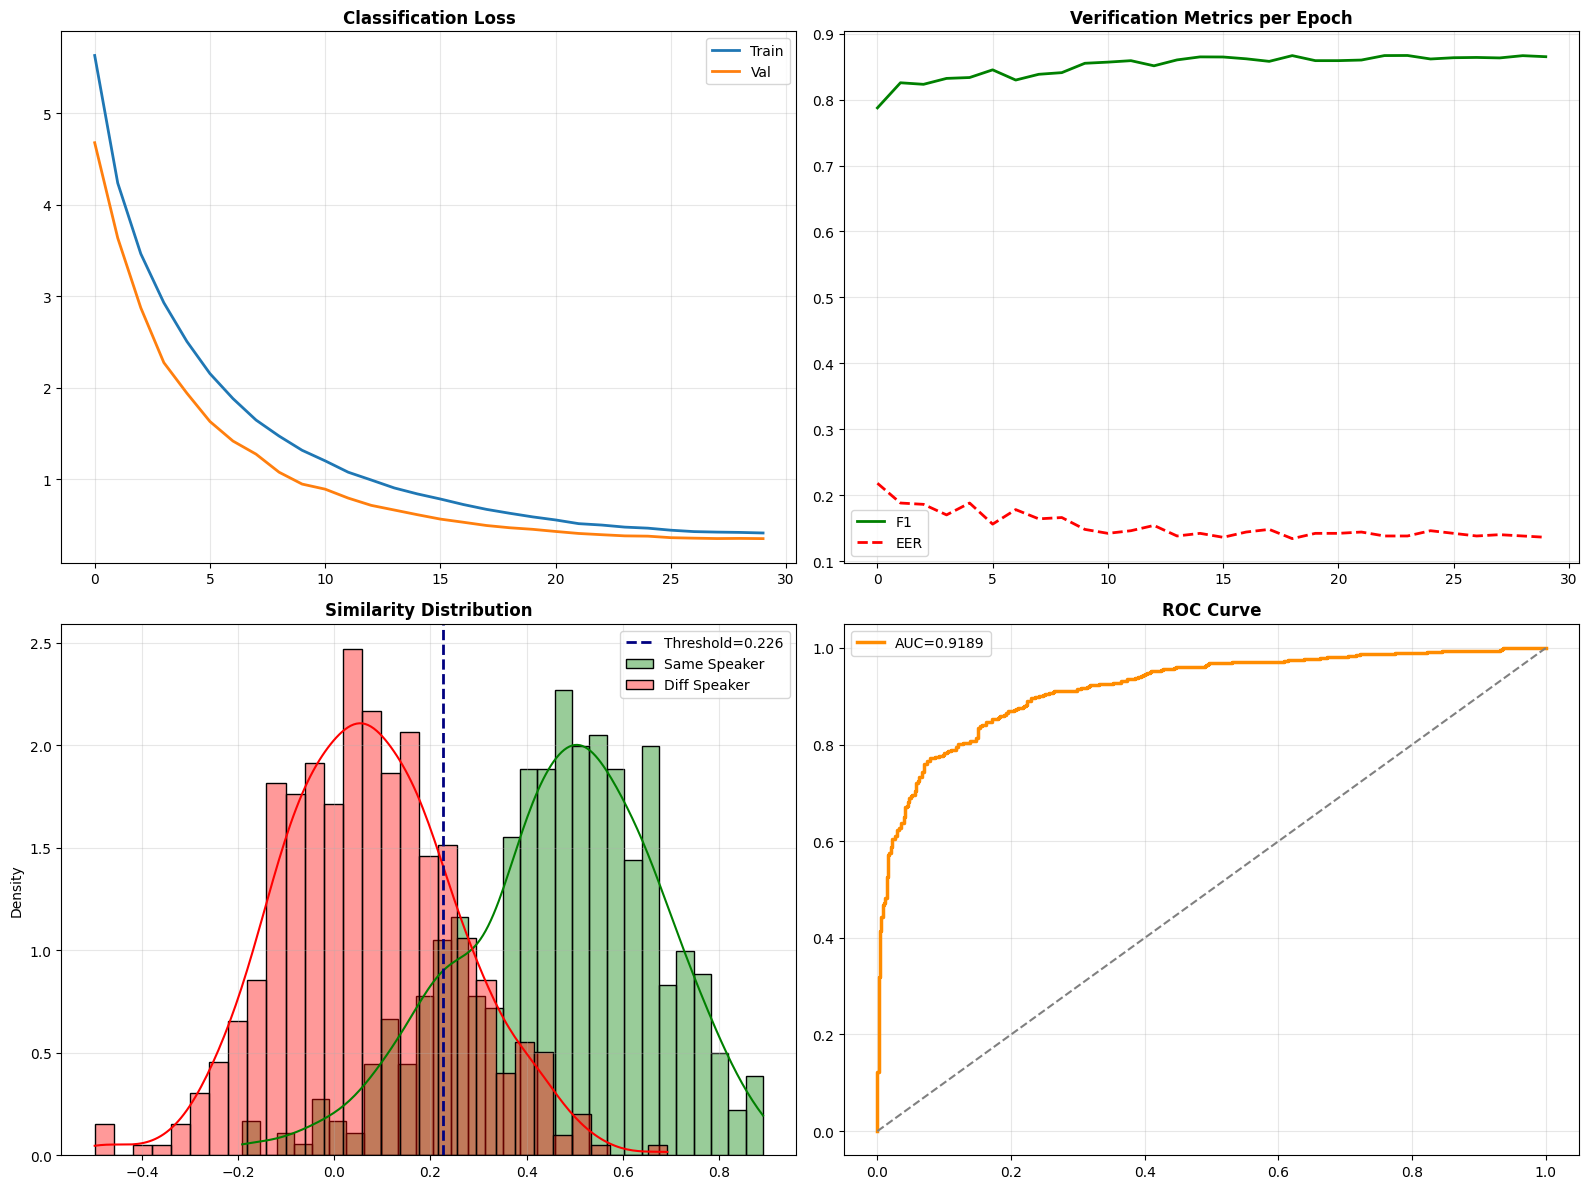

In [5]:
ckpt_path = 'checkpoints/xvector/best_model.pt'
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    eval_model = XVectorModel(N_MELS, NUM_CLASSES, 512)
    eval_model.load_state_dict(ckpt['model_state_dict'])
    eval_model = eval_model.to(device)
    opt_threshold = ckpt['optimal_threshold']
    print(f'Best model restored. Threshold: {opt_threshold:.3f}')
else:
    eval_model = model; opt_threshold = 0.5

tr = eval_verification(eval_model, test_pairs, mel_transform, device)
ts, tl = tr['sims'], tr['labels']
tp = (ts >= opt_threshold).astype(int)
tf1 = f1_score(tl, tp)
tacc = accuracy_score(tl, tp)
tprec = precision_score(tl, tp)
trec = recall_score(tl, tp)
fpr, tpr, _ = roc_curve(tl, ts)
tauc = auc(fpr, tpr)

print(f'\n{"="*50} TEST REPORT {"="*50}')
print(f'  Threshold: {opt_threshold:.3f}')
print(f'  F1: {tf1:.4f} | Acc: {tacc:.4f} | Prec: {tprec:.4f} | Rec: {trec:.4f}')
print(f'  EER: {tr["eer"]:.4f} | AUC: {tauc:.4f}')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes[0,0].plot(history['train_loss'], label='Train', lw=2)
axes[0,0].plot(history['val_loss'], label='Val', lw=2)
axes[0,0].set_title('Classification Loss', fontweight='bold'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(history['val_f1'], label='F1', color='green', lw=2)
axes[0,1].plot(history['val_eer'], label='EER', color='red', lw=2, ls='--')
axes[0,1].set_title('Verification Metrics per Epoch', fontweight='bold'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

sns.histplot(ts[tl==1], color='green', label='Same Speaker', kde=True, bins=30, stat='density', alpha=0.4, ax=axes[1,0])
sns.histplot(ts[tl==0], color='red', label='Diff Speaker', kde=True, bins=30, stat='density', alpha=0.4, ax=axes[1,0])
axes[1,0].axvline(opt_threshold, color='navy', ls='--', lw=2, label=f'Threshold={opt_threshold:.3f}')
axes[1,0].set_title('Similarity Distribution', fontweight='bold'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'AUC={tauc:.4f}')
axes[1,1].plot([0,1],[0,1],'--', color='grey')
axes[1,1].set_title('ROC Curve', fontweight='bold'); axes[1,1].legend(); axes[1,1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('results/xvector_evaluation_plots.png', dpi=150); plt.show()

## 🔊 Step 5.5: Fixed SNR Noisy Audio Evaluation
As requested, we run standard verification evaluations under fixed noise levels from the MUSAN noise dataset at **0dB, 10dB, and 20dB** to measure the robustness and degradation of our X-Vector model compared to the clean baseline.

## 💾 Step 6: Export Model for Comparison

In [6]:
def eval_verif_noise(mdl, pairs, mt, dev, snr_val):
    mdl.eval()
    sims, labs = [], []
    cache = {}
    for a, b, lb in tqdm(pairs, desc=f'Evaluating {snr_val}dB'):
        for f in [a, b]:
            if f not in cache:
                try:
                    w, _ = librosa.load(f, sr=16000)
                except Exception:
                    w = np.zeros(48000, dtype=np.float32)
                ns = 48000
                if len(w) < ns: w = np.pad(w, (0, ns-len(w)))
                else: w = w[:ns]
                
                # Mix in random MUSAN background noise at exactly the fixed SNR
                if len(noise_files) > 0:
                    try:
                        nw, _ = librosa.load(random.choice(noise_files), sr=16000)
                        if len(nw) < len(w):
                            nw = np.tile(nw, math.ceil(len(w)/len(nw)))[:len(w)]
                        else:
                            nw = nw[:len(w)]
                        clean_p = np.mean(w**2) + 1e-8
                        noise_p = np.mean(nw**2) + 1e-8
                        scale = math.sqrt(clean_p / noise_p * 10**(-snr_val/10))
                        w = w + scale * nw
                        mx = np.max(np.abs(w))
                        if mx > 1.0: w = w / mx
                    except Exception:
                        pass
                wt = torch.tensor(w, dtype=torch.float32).unsqueeze(0).to(dev)
                with torch.no_grad():
                    m = mt(wt)
                    lm = torch.log(m+1e-6); lm = lm - lm.mean()
                    m2 = mdl.module.extract_embedding(lm) if isinstance(mdl, nn.DataParallel) else mdl.extract_embedding(lm)
                cache[f] = F.normalize(m2, p=2, dim=1).cpu().numpy()[0]
        sims.append(np.dot(cache[a], cache[b]))
        labs.append(lb)
    del cache; gc.collect(); torch.cuda.empty_cache()
    sims, labs = np.array(sims), np.array(labs)
    preds = (sims >= opt_threshold).astype(int)
    fpr, tpr, _ = roc_curve(labs, sims)
    fnr = 1 - tpr
    eer = fpr[np.nanargmin(np.abs(fpr - fnr))]
    return {'f1': f1_score(labs, preds), 'eer': eer, 'accuracy': accuracy_score(labs, preds),
            'precision': precision_score(labs, preds, zero_division=0), 'recall': recall_score(labs, preds, zero_division=0)}

print('Evaluating X-Vector under noise stress test (0dB, 10dB, 20dB)...')
noise_results = {}
for snr in [20, 10, 0]:
    noise_results[snr] = eval_verif_noise(eval_model, test_pairs, mel_transform, device, snr)

print(f'\n{"="*50} NOISE STRESS TEST (X-VECTOR) {"="*50}')
print(f'  Clean Base  -> F1: {tf1:.4f} | EER: {tr["eer"]:.4f} | Accuracy: {tacc:.4f} | Precision: {tprec:.4f} | Recall: {trec:.4f}')
for snr in [20, 10, 0]:
    r = noise_results[snr]
    print(f'  SNR {snr:2d} dB   -> F1: {r["f1"]:.4f} | EER: {r["eer"]:.4f} | Accuracy: {r["accuracy"]:.4f} | Precision: {r["precision"]:.4f} | Recall: {r["recall"]:.4f}')


Evaluating X-Vector under noise stress test (0dB, 10dB, 20dB)...


Evaluating 0dB: 100%|██████████| 1000/1000 [01:47<00:00,  9.30it/s]



================================================== NOISE STRESS TEST (X-VECTOR) ==================================================
  Clean Base  -> F1: 0.8402 | EER: 0.1620 | Accuracy: 0.8360 | Precision: 0.8194 | Recall: 0.8620
  SNR 20 dB   -> F1: 0.8504 | EER: 0.1440 | Accuracy: 0.8480 | Precision: 0.8372 | Recall: 0.8640
  SNR 10 dB   -> F1: 0.8367 | EER: 0.1660 | Accuracy: 0.8360 | Precision: 0.8333 | Recall: 0.8400
  SNR  0 dB   -> F1: 0.7953 | EER: 0.2120 | Accuracy: 0.7920 | Precision: 0.7829 | Recall: 0.8080


In [7]:
torch.save({
    'model_architecture': 'XVectorModel',
    'input_dim': N_MELS, 'embedding_dim': 512, 'num_classes': NUM_CLASSES,
    'optimal_threshold': opt_threshold,
    'model_state_dict': eval_model.state_dict(),
    'spk_to_label': spk_to_label, 'label_to_spk': label_to_spk,
    'test_metrics': {'f1_score':tf1, 'eer':tr['eer'], 'accuracy':tacc,
                     'precision':tprec, 'recall':trec, 'auc':tauc}
}, 'results/xvector_final_model.pt')
print('[SUCCESS] X-Vector exported to results/xvector_final_model.pt')
v = torch.load('results/xvector_final_model.pt', map_location='cpu', weights_only=False)
print(f'  Arch: {v["model_architecture"]} | F1: {v["test_metrics"]["f1_score"]:.4f}')

[SUCCESS] X-Vector exported to results/xvector_final_model.pt
  Arch: XVectorModel | F1: 0.8402
